# Projet Titanic — Classification ML

Prédire la survie des passagers du Titanic à partir de leurs caractéristiques.
Ce projet couvre l'exploration, le nettoyage et la modélisation des données.

## 1. Importation des librairies et chargement des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
df = pd.read_csv('train.csv')

# Afficher les premières lignes
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploration des données (EDA)

On commence par comprendre la structure du dataset : dimensions, types de colonnes, et valeurs manquantes.

In [2]:
# Dimensions du dataset
print("Dimensions :", df.shape)
print()

# Types de colonnes et valeurs manquantes
print("Infos générales :")
df.info()

Dimensions : (891, 12)

Infos générales :
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Statistiques descriptives

Résumé statistique des colonnes numériques : moyenne, écart-type, min, max.

In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Visualisation des taux de survie

On explore la relation entre la survie et trois variables clés : le sexe, la classe et l'âge.

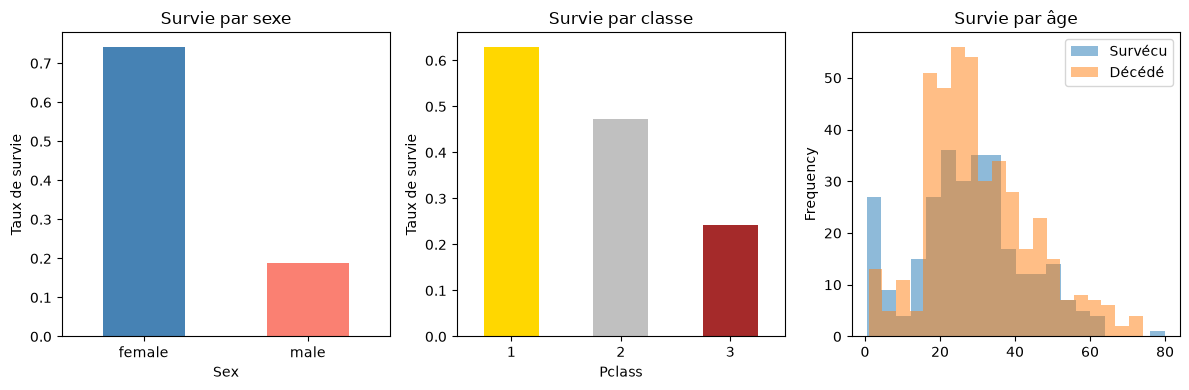

In [4]:
# Taux de survie par sexe
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Survie par sexe')
plt.ylabel('Taux de survie')
plt.xticks(rotation=0)

plt.subplot(1, 3, 2)
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['gold', 'silver', 'brown'])
plt.title('Survie par classe')
plt.ylabel('Taux de survie')
plt.xticks(rotation=0)

plt.subplot(1, 3, 3)
df[df['Survived']==1]['Age'].plot(kind='hist', alpha=0.5, label='Survécu', bins=20)
df[df['Survived']==0]['Age'].plot(kind='hist', alpha=0.5, label='Décédé', bins=20)
plt.title('Survie par âge')
plt.legend()

plt.tight_layout()
plt.show()

## 3. Nettoyage des données

On traite les valeurs manquantes :
- `Age` : 177 valeurs manquantes → remplacement par la médiane
- `Cabin` : 77% de valeurs manquantes → suppression de la colonne
- `Embarked` : 2 valeurs manquantes → remplacement par le mode

In [5]:
# 1. Remplir les âges manquants par la médiane
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Supprimer la colonne Cabin (trop de valeurs manquantes)
df = df.drop(columns=['Cabin'])

# 3. Remplir les 2 Embarked manquants par la valeur la plus fréquente
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Vérification — il ne doit plus y avoir de valeurs manquantes
print("Valeurs manquantes restantes :")
print(df.isnull().sum())

Valeurs manquantes restantes :
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 4. Encodage des variables catégorielles

scikit-learn ne comprend que des chiffres. On convertit :
- `Sex` : female=1, male=0
- `Embarked` : one-hot encoding (évite d'introduire un ordre artificiel)

In [6]:
# Convertir Sex en chiffres (female=1, male=0)
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})

# Convertir Embarked en colonnes binaires (one-hot encoding)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Vérification
print(df.columns.tolist())
print(df.head(3))

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S']
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   

             Ticket     Fare  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500       False        True  
1          PC 17599  71.2833       False       False  
2  STON/O2. 3101282   7.9250       False        True  


## 5. Préparation des données pour le modèle

On sélectionne les features pertinentes et on sépare X (variables d'entrée) et y (ground truth).

In [7]:
# Supprimer les colonnes inutiles pour le modèle
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

X = df[features]  # Variables d'entrée
y = df['Survived']  # Ground truth

print("X shape :", X.shape)
print("y shape :", y.shape)
print("\nAperçu de X :")
X.head(3)

X shape : (891, 8)
y shape : (891,)

Aperçu de X :


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,False,True
1,1,1,38.0,1,0,71.2833,False,False
2,3,1,26.0,0,0,7.9250,False,True


## 6. Séparation train/test et entraînement du modèle

On divise les données en deux ensembles :
- **Train (80%)** : le modèle apprend dessus
- **Test (20%)** : on évalue le modèle sur des données qu'il n'a jamais vues

On utilise un **Random Forest** : 100 arbres de décision entraînés en parallèle,
la prédiction finale est un vote majoritaire entre tous les arbres.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Taille train :", X_train.shape)
print("Taille test  :", X_test.shape)

# Entraînement du modèle
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\n Modèle entraîné !")

Taille train : (712, 8)
Taille test  : (179, 8)

 Modèle entraîné !


## 7. Évaluation du modèle

On évalue le modèle sur les données de test — des données qu'il n'a jamais vues pendant l'entraînement.

In [11]:
from sklearn.metrics import accuracy_score, classification_report

# Prédictions sur les données de test
y_pred = model.predict(X_test)

# Métriques
print("Accuracy :", accuracy_score(y_test, y_pred))
print()
print("Rapport complet :")
print(classification_report(y_test, y_pred, target_names=['Décédé', 'Survécu']))

Accuracy : 0.7988826815642458

Rapport complet :
              precision    recall  f1-score   support

      Décédé       0.82      0.84      0.83       105
     Survécu       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## 8. Importance des features

Quel est le poids de chaque variable dans les décisions du modèle ?

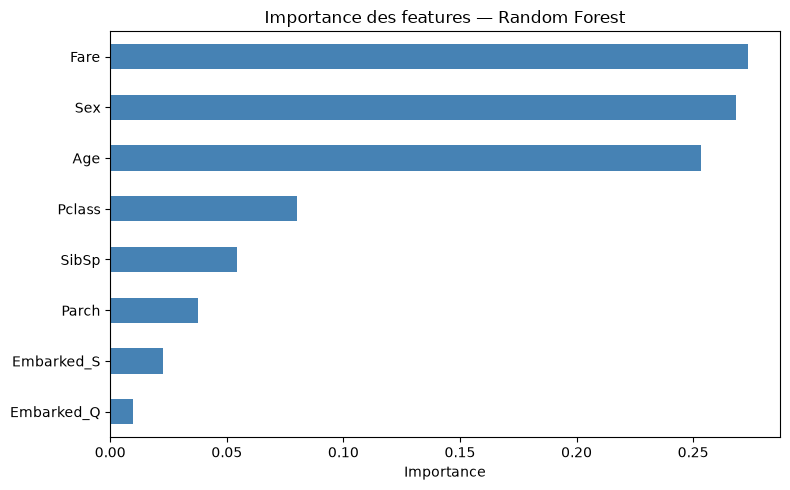

In [12]:
# Importance des features
importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title("Importance des features — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Sauvegarde du modèle

On sauvegarde le modèle entraîné pour pouvoir le réutiliser sans réentraîner.

In [15]:
import joblib

# Sauvegarder le modèle
joblib.dump(model, 'random_forest_titanic.pkl')
print("Modèle sauvegardé : random_forest_titanic.pkl")

Modèle sauvegardé : random_forest_titanic.pkl
